#8 - Evaluation and Interpretation of the Baseline

This notebook evaluates and interprets the baseline logistic regression from Task 7 with the full
suite of imbalanced-classification metrics and the diagnostics an examiner expects: precision,
recall, F1, ROC-AUC, PR-AUC, MCC and balanced accuracy at a justified operating point; confusion
matrices; probability calibration; permutation and coefficient feature importance; and an error
analysis by corridor and over time. It closes with strengths, weaknesses and implications for the
advanced tier

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, balanced_accuracy_score, brier_score_loss,
    confusion_matrix, precision_recall_curve)
mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":200,"font.size":11,"axes.grid":True,
    "grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False,"figure.autolayout":True})
ACCENT="#1F3864"; ORANGE="#C55A11"; RED="#B22222"; TEAL="#2E7D6F"
DATA=Path("data"); FIG=Path("eda_figures"); FIG.mkdir(exist_ok=True)
data=pd.read_parquet(DATA/"modelling_dataset.parquet").reset_index()
data['month']=pd.to_datetime(data['month']); data=data.sort_values('month').reset_index(drop=True)
FEATURES=[c for c in data.columns if 'rate_' in c]+['avg_tone','sum_log_sources']; HORIZONS=[30,60,90]
TEST_START=data['month'].max()-pd.DateOffset(months=24)
train=data[data['month']<TEST_START].copy(); test_t1=data[(data['month']>=TEST_START)&(data['tier']=='T1')].copy()

def fit(h):
    pipe=Pipeline([("scale",StandardScaler()),("lr",LogisticRegression(penalty="elasticnet",
          solver="saga",class_weight="balanced",max_iter=3000,random_state=0))])
    gs=GridSearchCV(pipe,{"lr__C":[0.1,1.0],"lr__l1_ratio":[0.2,0.8]},
          scoring="average_precision",cv=TimeSeriesSplit(3),n_jobs=-1).fit(train[FEATURES],train['y_%dd'%h])
    return gs.best_estimator_
models={h:fit(h) for h in HORIZONS}
print("fitted horizons:",list(models))

fitted horizons: [30, 60, 90]


In [3]:
def best_threshold(y,proba):
    pr,rc,th=precision_recall_curve(y,proba)
    f1=2*pr*rc/(pr+rc+1e-9); k=int(np.nanargmax(f1[:-1])); return float(th[k])
THR={}
for h in HORIZONS:
    ptr=models[h].predict_proba(train[FEATURES])[:,1]
    THR[h]=best_threshold(train['y_%dd'%h].values, ptr)
print("F1-optimal thresholds (chosen on train):",{h:round(THR[h],3) for h in HORIZONS})

F1-optimal thresholds (chosen on train): {30: 0.668, 60: 0.507, 90: 0.5}


## 2. Full metric suite (imbalanced classification)

In [4]:
def row(h,thr,tag):
    y=test_t1['y_%dd'%h].values; proba=models[h].predict_proba(test_t1[FEATURES])[:,1]
    pred=(proba>=thr).astype(int)
    return {"horizon":f"y_{h}d","threshold":tag,
        "precision":round(precision_score(y,pred,zero_division=0),3),
        "recall":round(recall_score(y,pred),3),"F1":round(f1_score(y,pred),3),
        "MCC":round(matthews_corrcoef(y,pred),3),"bal_acc":round(balanced_accuracy_score(y,pred),3),
        "ROC_AUC":round(roc_auc_score(y,proba),3),"PR_AUC":round(average_precision_score(y,proba),3),
        "Brier":round(brier_score_loss(y,proba),3)}
rows=[]
for h in HORIZONS: rows.append(row(h,0.5,"0.50"))
for h in HORIZONS: rows.append(row(h,THR[h],"F1-opt"))
metrics=pd.DataFrame(rows); metrics.to_csv(DATA/"baseline_eval_metrics.csv",index=False); metrics

,horizon,threshold,precision,recall,F1,MCC,bal_acc,ROC_AUC,PR_AUC,Brier
0,y_30d,0.50,0.207,0.559,0.302,0.111,0.575,0.597,0.237,0.239
1,y_60d,0.50,0.341,0.642,0.445,0.138,0.577,0.638,0.483,0.238
2,y_90d,0.50,0.415,0.642,0.504,0.137,0.571,0.613,0.516,0.243
3,y_30d,F1-opt,0.231,0.044,0.074,0.034,0.508,0.597,0.237,0.239
4,y_60d,F1-opt,0.374,0.508,0.431,0.161,0.587,0.638,0.483,0.238
5,y_90d,F1-opt,0.415,0.642,0.504,0.137,0.571,0.613,0.516,0.243


## 3. Confusion matrices (F1-optimal threshold)

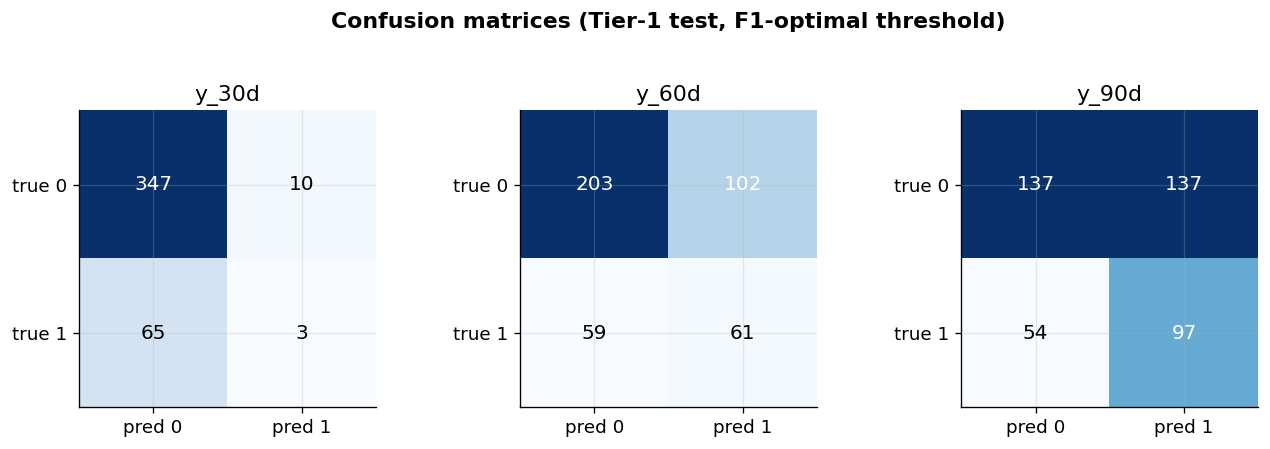

In [9]:
fig,axes=plt.subplots(1,3,figsize=(12,3.6))
for ax,h in zip(axes,HORIZONS):
    y=test_t1['y_%dd'%h].values; proba=models[h].predict_proba(test_t1[FEATURES])[:,1]
    cm=confusion_matrix(y,(proba>=THR[h]).astype(int))
    im=ax.imshow(cm,cmap='Blues')
    for (i,j),v in np.ndenumerate(cm): ax.text(j,i,int(v),ha='center',va='center',
        color='white' if v>cm.max()/2 else 'black',fontsize=12)
    ax.set_xticks([0,1]); ax.set_xticklabels(['pred 0','pred 1']); ax.set_yticks([0,1]); ax.set_yticklabels(['true 0','true 1'])
    ax.set_title(f"y_{h}d")
plt.suptitle("Confusion matrices (Tier-1 test, F1-optimal threshold)",y=1.03,fontweight='bold')
plt.savefig(FIG/"eval_confusion_F1.png",bbox_inches='tight'); plt.show()

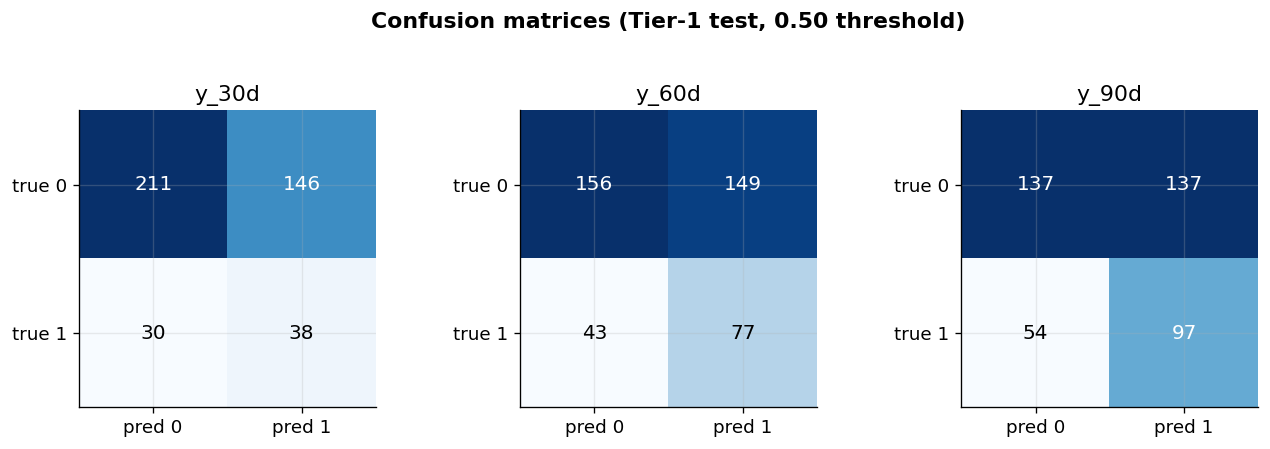

In [10]:
fig,axes=plt.subplots(1,3,figsize=(12,3.6))
for ax,h in zip(axes,HORIZONS):
    y=test_t1['y_%dd'%h].values; proba=models[h].predict_proba(test_t1[FEATURES])[:,1]
    cm=confusion_matrix(y,(proba>=0.5).astype(int))
    im=ax.imshow(cm,cmap='Blues')
    for (i,j),v in np.ndenumerate(cm): ax.text(j,i,int(v),ha='center',va='center',
        color='white' if v>cm.max()/2 else 'black',fontsize=12)
    ax.set_xticks([0,1]); ax.set_xticklabels(['pred 0','pred 1']); ax.set_yticks([0,1]); ax.set_yticklabels(['true 0','true 1'])
    ax.set_title(f"y_{h}d")
plt.suptitle("Confusion matrices (Tier-1 test, 0.50 threshold)",y=1.03,fontweight='bold')
plt.savefig(FIG/"eval_confusion.png",bbox_inches='tight'); plt.show()

## 4. Probability calibration

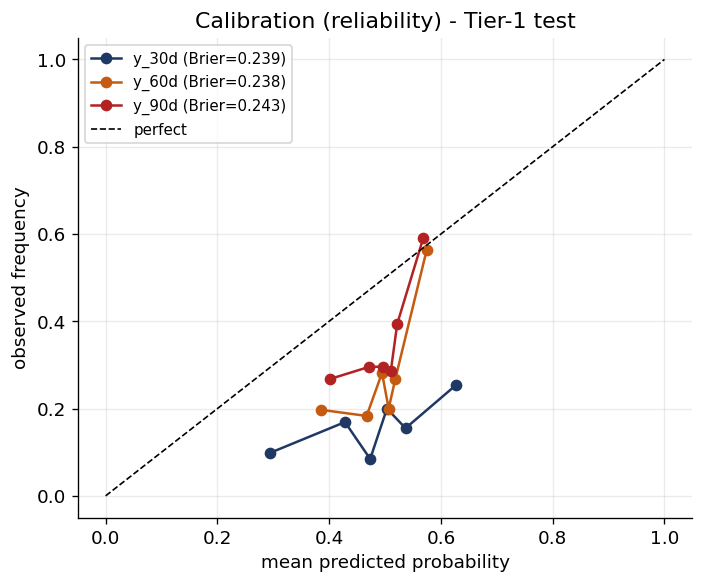

In [5]:
fig,ax=plt.subplots(figsize=(6,5))
for h,col in zip(HORIZONS,[ACCENT,ORANGE,RED]):
    y=test_t1['y_%dd'%h].values; proba=models[h].predict_proba(test_t1[FEATURES])[:,1]
    fr,mp=calibration_curve(y,proba,n_bins=6,strategy='quantile')
    ax.plot(mp,fr,'o-',color=col,label=f"y_{h}d (Brier={brier_score_loss(y,proba):.3f})")
ax.plot([0,1],[0,1],'k--',lw=1,label='perfect')
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Calibration (reliability) - Tier-1 test"); ax.legend(fontsize=9)
plt.savefig(FIG/"eval_calibration.png",bbox_inches='tight'); plt.show()

## 5. Feature importance: coefficients and permutation importance

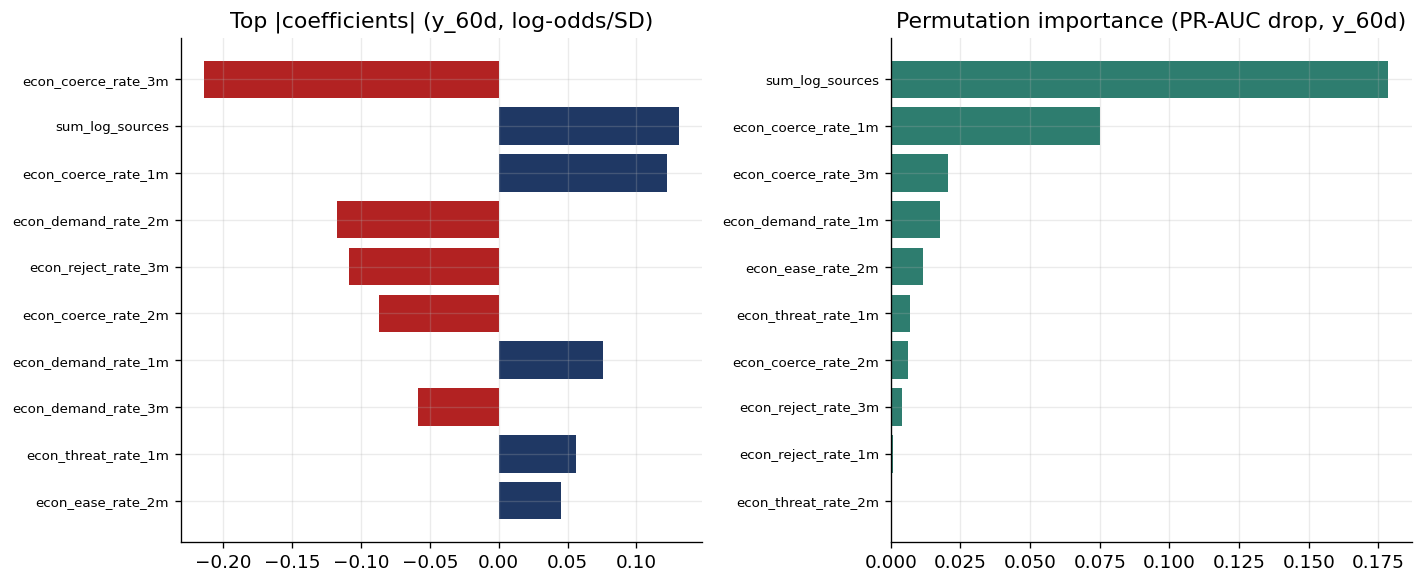

Top permutation-importance features (y_60d):
sum_log_sources        0.1783
econ_coerce_rate_1m    0.0752
econ_coerce_rate_3m    0.0205
econ_demand_rate_1m    0.0177
econ_ease_rate_2m      0.0115
econ_threat_rate_1m    0.0069


In [6]:
h=60  # the best-performing horizon
best=models[h]; y=test_t1['y_%dd'%h].values
coef=pd.Series(best.named_steps['lr'].coef_[0],index=FEATURES)
pi=permutation_importance(best,test_t1[FEATURES],y,scoring='average_precision',n_repeats=15,random_state=0)
imp=pd.Series(pi.importances_mean,index=FEATURES)
top=imp.sort_values().tail(10)
fig,axes=plt.subplots(1,2,figsize=(12,5))
c2=coef.reindex(coef.abs().sort_values().tail(10).index)
axes[0].barh(range(len(c2)),c2.values,color=[RED if v<0 else ACCENT for v in c2.values])
axes[0].set_yticks(range(len(c2))); axes[0].set_yticklabels(c2.index,fontsize=8); axes[0].set_title(f"Top |coefficients| (y_{h}d, log-odds/SD)")
axes[1].barh(range(len(top)),top.values,color=TEAL)
axes[1].set_yticks(range(len(top))); axes[1].set_yticklabels(top.index,fontsize=8); axes[1].set_title(f"Permutation importance (PR-AUC drop, y_{h}d)")
plt.savefig(FIG/"eval_importance.png",bbox_inches='tight'); plt.show()
print("Top permutation-importance features (y_60d):")
print(imp.sort_values(ascending=False).head(6).round(4).to_string())

## 6. Error analysis - by corridor and over time

In [7]:
h=60; y=test_t1['y_%dd'%h].values; proba=models[h].predict_proba(test_t1[FEATURES])[:,1]
te=test_t1.copy(); te['y']=y; te['pred']=(proba>=THR[h]).astype(int); te['proba']=proba
te['err']=np.where((te.y==1)&(te.pred==0),'FN',np.where((te.y==0)&(te.pred==1),'FP',
          np.where((te.y==1)&(te.pred==1),'TP','TN')))
print("Confusion counts (y_60d):", te['err'].value_counts().to_dict())
# per-corridor recall on positives
g=te[te.y==1].groupby('pair_str').agg(pos=('y','size'),caught=('pred','sum'))
g['recall']=(g['caught']/g['pos']).round(2); g=g.sort_values('recall')
print("\nPer-corridor recall (corridors with >=3 positives), worst first:")
print(g[g['pos']>=3].to_string())

Confusion counts (y_60d): {'TN': 203, 'FP': 102, 'TP': 61, 'FN': 59}

Per-corridor recall (corridors with >=3 positives), worst first:
          pos  caught  recall
pair_str                     
EUR-IND     6       1    0.17
EUR-KOR     6       1    0.17
EUR-JPN     6       1    0.17
EUR-MEX     6       1    0.17
BRA-USA    12       3    0.25
BRA-EUR     7       2    0.29
CAN-USA    10       5    0.50
MEX-USA    10       5    0.50
IND-USA    11       6    0.55
CHN-EUR     6       4    0.67
KOR-USA    10       7    0.70
CHN-USA    12      11    0.92
EUR-USA    14      13    0.93


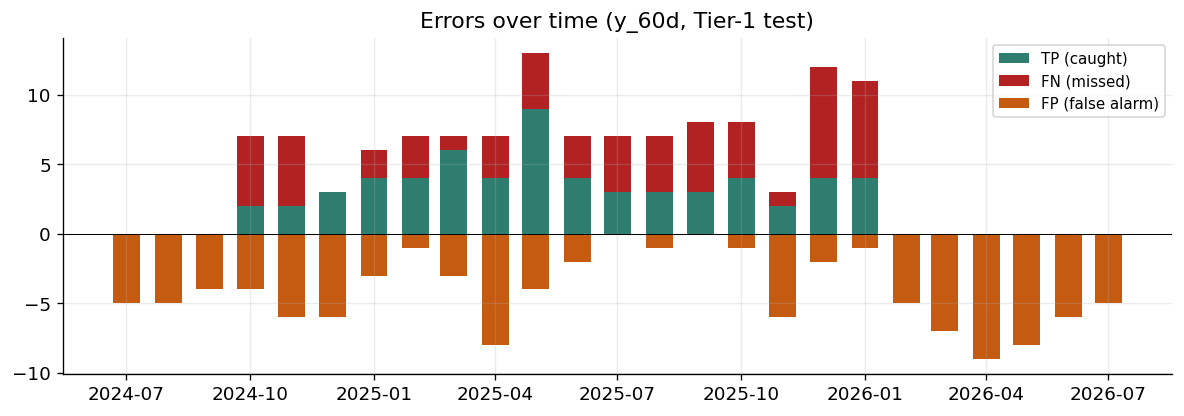

In [8]:
# errors over time (monthly FN and FP counts)
te['m']=te['month'].values.astype('datetime64[M]')
bym=te.groupby('m')['err'].value_counts().unstack(fill_value=0)
for c in ['FN','FP','TP']:
    if c not in bym: bym[c]=0
fig,ax=plt.subplots(figsize=(10,3.6))
ax.bar(bym.index,bym['TP'],width=20,color=TEAL,label='TP (caught)')
ax.bar(bym.index,bym['FN'],width=20,bottom=bym['TP'],color=RED,label='FN (missed)')
ax.bar(bym.index,-bym['FP'],width=20,color=ORANGE,label='FP (false alarm)')
ax.axhline(0,color='k',lw=0.6); ax.set_title("Errors over time (y_60d, Tier-1 test)"); ax.legend(fontsize=9)
plt.savefig(FIG/"eval_errors_time.png",bbox_inches='tight'); plt.show()

In [9]:
print("saved -> data/baseline_eval_metrics.csv")
print(metrics.to_string(index=False))

saved -> data/baseline_eval_metrics.csv
horizon threshold  precision  recall    F1   MCC  bal_acc  ROC_AUC  PR_AUC  Brier
  y_30d      0.50      0.207   0.559 0.302 0.111    0.575    0.597   0.237  0.239
  y_60d      0.50      0.341   0.642 0.445 0.138    0.577    0.638   0.483  0.238
  y_90d      0.50      0.415   0.642 0.504 0.137    0.571    0.613   0.516  0.243
  y_30d    F1-opt      0.231   0.044 0.074 0.034    0.508    0.597   0.237  0.239
  y_60d    F1-opt      0.374   0.508 0.431 0.161    0.587    0.638   0.483  0.238
  y_90d    F1-opt      0.415   0.642 0.504 0.137    0.571    0.613   0.516  0.243
